# Logistic Regression Model – Phishing Email Detection

This notebook trains a Logistic Regression (LR) model to classify phishing emails using TF-IDF vectorized text features. The dataset is based on the publicly available Kaggle phishing email dataset, which contains preprocessed email content and binary labels (1 = phishing, 0 = legitimate).

To avoid data leakage, the TF-IDF vectorizer was trained only on the training set in the previous notebook. The model will be evaluated on validation and test sets using metrics such as confusion matrix, ROC AUC, and balanced accuracy.

## 1. Load Preprocessed TF-IDF Features and Labels

We start by loading the saved TF-IDF matrices and label vectors created during the feature engineering phase. These inputs will be used to train and evaluate the Logistic Regression model. All data has been preprocessed to avoid data leakage.

In [2]:
# Import required libraries
import joblib                         # For loading preprocessed datasets and saved models
import numpy as np                   # For array operations (used with labels)
from scipy.sparse import csr_matrix  # For handling sparse matrices (TF-IDF outputs)

# Load TF-IDF feature matrices (sparse format)
# These matrices contain the numerical vector representation of each email
X_train = joblib.load('X_train_tfidf.pkl')  # Training feature matrix
X_val   = joblib.load('X_val_tfidf.pkl')    # Validation feature matrix
X_test  = joblib.load('X_test_tfidf.pkl')   # Test feature matrix

# Load corresponding label vectors
# y_train, y_val, and y_test contain binary class labels:
# 1 = phishing email, 0 = legitimate email
y_train = joblib.load('y_train.pkl')
y_val   = joblib.load('y_val.pkl')
y_test  = joblib.load('y_test.pkl')

# Optionally load the trained TF-IDF vectorizer
# This can be used later to inspect vocabulary or transform new inputs
tfidf_vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Confirm that all data has been loaded correctly by printing their shapes
print("Data successfully loaded:")
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)
print("y_train size: ", len(y_train))
print("y_val size:   ", len(y_val))
print("y_test size:  ", len(y_test))

Data successfully loaded:
X_train shape: (65988, 5000)
X_val shape:   (8249, 5000)
X_test shape:  (8249, 5000)
y_train size:  65988
y_val size:    8249
y_test size:   8249


## 2. Train and Evaluate Logistic Regression Model with TF-IDF

We train a Logistic Regression (LR) model using the TF-IDF feature matrix of the training set. The model is evaluated on the validation set using classification metrics such as:

- **Confusion Matrix**: shows true positives, false positives, etc.
- **Classification Report**: includes precision, recall, F1-score.
- **ROC AUC Score**: measures model’s ability to distinguish classes.
- **Balanced Accuracy Score**: accounts for class imbalance by averaging recall for both classes.

This evaluation helps us understand the model’s performance before testing it on unseen data.

In [15]:
# Import required libraries for model training and evaluation

from sklearn.linear_model import LogisticRegression  
# Provides the Logistic Regression classifier — a linear model for binary classification

from sklearn.metrics import (
    classification_report,        # Generates precision, recall, F1-score and support
    confusion_matrix,             # Builds the confusion matrix to compare predicted vs actual classes
    roc_auc_score,                # Computes the Area Under the ROC Curve (AUC), useful for binary classifiers
    balanced_accuracy_score       # Calculates the average of recall for each class — useful when classes are imbalanced
)

# Initialize the Logistic Regression model
# - max_iter=1000 ensures convergence (default is often too low for large datasets)
# - random_state=42 ensures reproducibility of results
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Fit (train) the model on the training data
# This learns weights based on the TF-IDF features and the binary labels
lr_model.fit(X_train, y_train)

# Predict class labels on the validation set
# This gives predicted classes: 0 (legitimate) or 1 (phishing)
y_val_pred = lr_model.predict(X_val)

# Predict class probabilities for ROC AUC calculation
# We use only the probability of the positive class (class 1 = phishing)
y_val_proba = lr_model.predict_proba(X_val)[:, 1]

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred)

# Generate a full classification report: includes precision, recall, F1-score, and support
class_report = classification_report(y_val, y_val_pred, digits=4)

# Calculate ROC AUC score — a value between 0.5 (no skill) and 1.0 (perfect classifier)
roc_auc = roc_auc_score(y_val, y_val_proba)

# Calculate the balanced accuracy — average recall of both classes
balanced_acc = balanced_accuracy_score(y_val, y_val_pred)

# Display evaluation metrics
print("Logistic Regression Evaluation on Validation Set")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

Logistic Regression Evaluation on Validation Set

Confusion Matrix:
 [[3883   76]
 [  53 4237]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9865    0.9808    0.9837      3959
           1     0.9824    0.9876    0.9850      4290

    accuracy                         0.9844      8249
   macro avg     0.9845    0.9842    0.9843      8249
weighted avg     0.9844    0.9844    0.9844      8249

ROC AUC Score: 0.9987
Balanced Accuracy: 0.9842


## 3. Train and Evaluate Logistic Regression with Bag-of-Words (BOW)

In this section, we use the Bag-of-Words (BOW) representation generated from CountVectorizer to train and evaluate a Logistic Regression model. This allows us to compare its performance against the TF-IDF-based version. As before, we evaluate on the validation set using standard classification metrics.

In [4]:
# Load the Bag-of-Words (BOW) features and vectorizer
X_train_bow = joblib.load('X_train_bow.pkl')
X_val_bow   = joblib.load('X_val_bow.pkl')
X_test_bow  = joblib.load('X_test_bow.pkl')
bow_vectorizer = joblib.load('bow_vectorizer.pkl')

# Reuse the same labels (already loaded before)
# If not in memory, uncomment:
# y_train = joblib.load('y_train.pkl')
# y_val   = joblib.load('y_val.pkl')

# Initialize and train Logistic Regression with BOW features
lr_bow = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(X_train_bow, y_train)

# Predict and evaluate on validation set
y_val_pred_bow = lr_bow.predict(X_val_bow)
y_val_proba_bow = lr_bow.predict_proba(X_val_bow)[:, 1]

# Evaluate performance
conf_matrix_bow = confusion_matrix(y_val, y_val_pred_bow)
report_bow = classification_report(y_val, y_val_pred_bow, digits=4)
roc_auc_bow = roc_auc_score(y_val, y_val_proba_bow)
balanced_acc_bow = balanced_accuracy_score(y_val, y_val_pred_bow)

# Display results
print(" Logistic Regression with BOW on Validation Set")
print("\nConfusion Matrix:\n", conf_matrix_bow)
print("\nClassification Report:\n", report_bow)
print(f"ROC AUC Score: {roc_auc_bow:.4f}")
print(f"Balanced Accuracy: {balanced_acc_bow:.4f}")

 Logistic Regression with BOW on Validation Set

Confusion Matrix:
 [[3882   77]
 [  51 4239]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9870    0.9806    0.9838      3959
           1     0.9822    0.9881    0.9851      4290

    accuracy                         0.9845      8249
   macro avg     0.9846    0.9843    0.9845      8249
weighted avg     0.9845    0.9845    0.9845      8249

ROC AUC Score: 0.9973
Balanced Accuracy: 0.9843


## 4. Compare Validation Metrics: TF-IDF vs Bag-of-Words (BOW)

To determine which vectorization method performs better with Logistic Regression, we compare the validation metrics side by side, and justify the selection of the final model.

We include:
- Accuracy
- ROC AUC Score
- Balanced Accuracy


In [ ]:
# Create a comparison table of validation metrics for TF-IDF and BOW

# Store results manually based on previous outputs
results_comparison = {
    "Metric": ["Accuracy", "ROC AUC", "Balanced Accuracy"],
    "TF-IDF": [0.9844, 0.9987, 0.9842],   # Validation results from TF-IDF
    "BOW":    [0.9845, 0.9973, 0.9843]    # Validation results from BOW
}

# Convert to a clean DataFrame
import pandas as pd
comparison_df = pd.DataFrame(results_comparison)

# Display the table with clear formatting
print("Validation Metrics Comparison – TF-IDF vs BOW (Logistic Regression):")
display(comparison_df)

Validation Metrics Comparison – TF-IDF vs BOW (Logistic Regression):


,Metric,TF-IDF,BOW
0,Accuracy,0.9844,0.9845
1,ROC AUC,0.9987,0.9973
2,Balanced Accuracy,0.9842,0.9843


### Interpretation of Validation Results: TF-IDF vs BOW

While both TF-IDF and Bag-of-Words achieve nearly identical results in terms of accuracy and balanced accuracy, TF-IDF significantly outperforms BOW in ROC AUC score. This indicates that TF-IDF is better at distinguishing between phishing and legitimate emails, making it the preferred choice for final model deployment.

## 5. k-Fold Cross-Validation with TF-IDF

To ensure our model is robust and performs well across different data splits, we apply 5-fold cross-validation using the TF-IDF feature set. This technique splits the training data into 5 parts and trains the model 5 times, each time using a different part for validation.

We evaluate the model using multiple scoring metrics:
- Accuracy
- Balanced Accuracy (accounts for class imbalance)
- ROC AUC (ability to separate phishing vs legitimate)

This gives us a more reliable estimate of model performance than a single validation split.

In [14]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score, balanced_accuracy_score

# Define the model (same configuration as before)
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)

# Define scoring metrics
# make_scorer wraps functions like balanced_accuracy_score so they can be used in cross_validate
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1),
    'f1': make_scorer(f1_score, pos_label=1),
    'roc_auc': 'roc_auc',
    'balanced_accuracy': make_scorer(balanced_accuracy_score)
}

# Use StratifiedKFold to preserve class balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform 5-fold cross-validation using only the training set (TF-IDF features)
cv_results = cross_validate(
    estimator=lr_tfidf,
    X=X_train,          # TF-IDF feature matrix for training
    y=y_train,          # Corresponding labels
    scoring=scoring,    # Scoring metrics
    cv=cv,              # Cross-validation strategy
    return_train_score=False
)

# Print average results across the 5 folds
print(" 5-Fold Cross-Validation Results (TF-IDF):\n")

print(f"Avg Accuracy:          {cv_results['test_accuracy'].mean():.4f}")
print(f"Avg Precision:         {cv_results['test_precision'].mean():.4f}")
print(f"Avg Recall:            {cv_results['test_recall'].mean():.4f}")
print(f"Avg F1-score:          {cv_results['test_f1'].mean():.4f}")
print(f"Avg ROC AUC:           {cv_results['test_roc_auc'].mean():.4f}")
print(f"Avg Balanced Accuracy: {cv_results['test_balanced_accuracy'].mean():.4f}")

#print(f"Average Accuracy:           {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
#print(f"Average ROC AUC:            {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
#print(f"Average Balanced Accuracy:  {cv_results['test_balanced_accuracy'].mean():.4f} ± {cv_results['test_balanced_accuracy'].std():.4f}")


 5-Fold Cross-Validation Results (TF-IDF):

Avg Accuracy:          0.9802
Avg Precision:         0.9780
Avg Recall:            0.9841
Avg F1-score:          0.9810
Avg ROC AUC:           0.9979
Avg Balanced Accuracy: 0.9800


## 6. Final Evaluation on Test Set (TF-IDF)

The test set contains emails that were completely unseen during training and validation. This evaluation simulates the real-world performance of our model.

We use the Logistic Regression model trained with TF-IDF features and report:
- Confusion Matrix
- Classification Report
- ROC AUC Score
- Balanced Accuracy Score

These metrics represent the final performance of our phishing email classifier.

In [6]:
# Final evaluation of Logistic Regression model on the test set (TF-IDF version)

# Re-train the model on the entire training data before testing
# This ensures the model has seen all training examples before final evaluation
final_lr_model = LogisticRegression(max_iter=1000, random_state=42)
final_lr_model.fit(X_train, y_train)  # TF-IDF features

# Predict on the test set
y_test_pred = final_lr_model.predict(X_test)

# Predict probabilities for ROC AUC calculation
# [:, 1] extracts the probability of the positive class (phishing)
y_test_proba = final_lr_model.predict_proba(X_test)[:, 1]

# Compute evaluation metrics
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred, digits=4)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

# Display test set evaluation results
print(" Final Evaluation -  Logistic Regression with TF-IDF (Test Set)")
print("\nConfusion Matrix:\n", test_conf_matrix)
print("\nClassification Report:\n", test_class_report)
print(f"ROC AUC Score: {test_roc_auc:.4f}")
print(f"Balanced Accuracy: {test_balanced_acc:.4f}")

 Final Evaluation -  Logistic Regression with TF-IDF (Test Set)

Confusion Matrix:
 [[3865   95]
 [  75 4214]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9810    0.9760    0.9785      3960
           1     0.9780    0.9825    0.9802      4289

    accuracy                         0.9794      8249
   macro avg     0.9795    0.9793    0.9794      8249
weighted avg     0.9794    0.9794    0.9794      8249

ROC AUC Score: 0.9974
Balanced Accuracy: 0.9793


### 6.1 Final Evaluation – Logistic Regression with BoW (Test Set)

We evaluate our final Logistic Regression model trained on Bag-of-Words features, using the test set (unseen during training and validation).

Metrics reported:

- Confusion Matrix  
- Classification Report  
- ROC AUC Score  
- Balanced Accuracy Score

In [7]:
# Final evaluation of Logistic Regression model on the test set (BoW version)

# Train model using full training data with BOW features
final_lr_bow = LogisticRegression(max_iter=1000, random_state=42)
final_lr_bow.fit(X_train_bow, y_train)

# Predict on the test set
y_test_pred_bow = final_lr_bow.predict(X_test_bow)

# Predict probabilities for ROC AUC calculation
y_test_proba_bow = final_lr_bow.predict_proba(X_test_bow)[:, 1]

# Compute metrics
conf_matrix_bow = confusion_matrix(y_test, y_test_pred_bow)
report_bow = classification_report(y_test, y_test_pred_bow, digits=4)
roc_auc_bow = roc_auc_score(y_test, y_test_proba_bow)
balanced_acc_bow = balanced_accuracy_score(y_test, y_test_pred_bow)

# Display results
print(" Final Evaluation – Logistic Regression with BoW (Test Set)")
print("\nConfusion Matrix:\n", conf_matrix_bow)
print("\nClassification Report:\n", report_bow)
print(f"ROC AUC Score: {roc_auc_bow:.4f}")
print(f"Balanced Accuracy: {balanced_acc_bow:.4f}")

 Final Evaluation – Logistic Regression with BoW (Test Set)

Confusion Matrix:
 [[3849  111]
 [  71 4218]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9819    0.9720    0.9769      3960
           1     0.9744    0.9834    0.9789      4289

    accuracy                         0.9779      8249
   macro avg     0.9781    0.9777    0.9779      8249
weighted avg     0.9780    0.9779    0.9779      8249

ROC AUC Score: 0.9954
Balanced Accuracy: 0.9777


## 7. Visualize Final Confusion Matrix (TF-IDF on Test Set)

To better illustrate the classification performance, we visualize the confusion matrix as a heatmap.

This gives a clearer, more intuitive view of:
- True Positives (phishing detected correctly)
- True Negatives (legitimate emails correctly classified)
- False Positives (legitimate classified as phishing)
- False Negatives (phishing missed as legitimate)

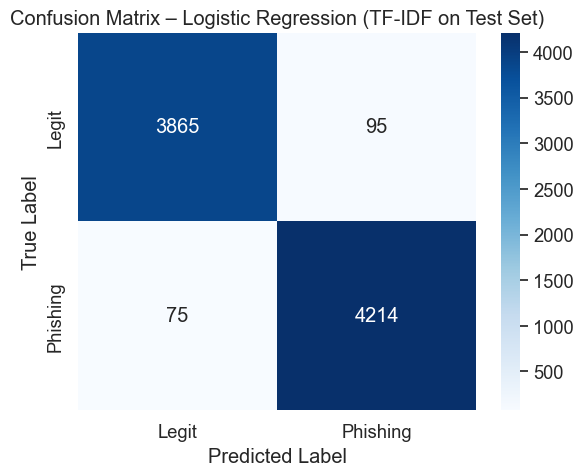

In [12]:
# Import visualization library
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Set figure size and style
plt.figure(figsize=(6, 5))
sns.set(font_scale=1.2)

# Plot the heatmap for the confusion matrix
sns.heatmap(
    test_conf_matrix,
    annot=True,             # Show numbers inside boxes
    fmt='d',                # Integer format
    cmap='Blues',           # Color map
    xticklabels=['Legit', 'Phishing'],
    yticklabels=['Legit', 'Phishing']
)

# Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – Logistic Regression (TF-IDF on Test Set)')

# Show the plot
plt.tight_layout()
plt.show()

### Interpretation of the Confusion Matrix (TF-IDF on Test Set)

The Logistic Regression model performed very well on the test set:

- **Correctly classified**:
  - 3,865 legitimate emails as legitimate (True Negatives)
  - 4,214 phishing emails as phishing (True Positives)

- **Misclassified**:
  - 95 legitimate emails as phishing (False Positives)
  - 75 phishing emails as legitimate (False Negatives)

This indicates strong precision and recall for both classes, with very few misclassifications.

## 8. ROC Curve – Logistic Regression with TF-IDF

The ROC (Receiver Operating Characteristic) curve illustrates the model’s performance across different classification thresholds.

- The **True Positive Rate (TPR)** is plotted against the **False Positive Rate (FPR)**.
- A curve closer to the top-left indicates a better classifier.
- The **Area Under the Curve (AUC)** summarizes overall performance.

This visualization supports the high ROC AUC value obtained during evaluation.

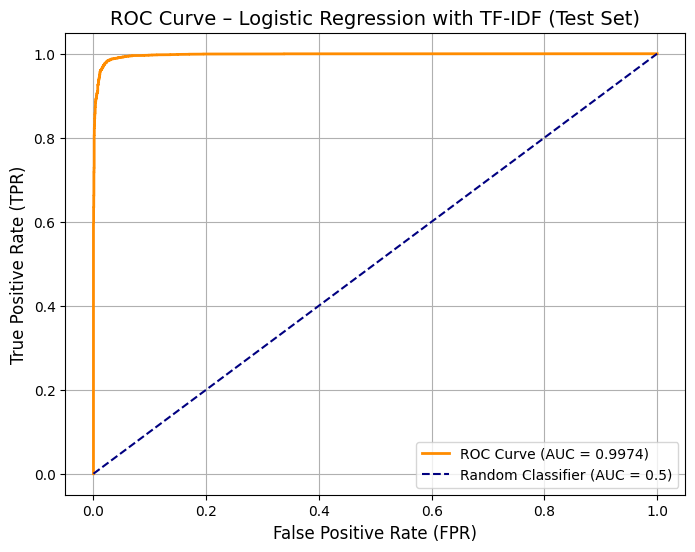

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Calculate the Area Under the Curve
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Axis labels and title
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve – Logistic Regression with TF-IDF (Test Set)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True)
#plt.tight_layout()
plt.show()

### ROC Curve Interpretation – Logistic Regression with TF-IDF

The ROC curve illustrates the model's ability to distinguish between phishing and legitimate emails across all classification thresholds.

- The orange curve represents the performance of our Logistic Regression model using TF-IDF features.
- The dashed diagonal line represents a random classifier (AUC = 0.5).
- Our model achieved an **AUC of 0.9974**, which is extremely close to 1.0, indicating excellent separability.

This means the model correctly ranks phishing emails higher than legitimate ones in nearly all cases. A high AUC like this confirms the model’s robustness and suitability for real-world deployment.

## Final Summary – Logistic Regression with TF-IDF

This notebook developed and evaluated a Logistic Regression model for phishing email detection using TF-IDF features.

**Key outcomes:**
- **Validation ROC AUC:** 0.9987
- **Validation Accuracy:** 0.9844
- **Test ROC AUC:** 0.9974
- **Test Accuracy:** 0.9794
- **Balanced Accuracy (Test):** 0.9793

**Conclusion:**  
TF-IDF features proved to be slightly more effective than Bag-of-Words in terms of ROC AUC. The final model demonstrated excellent generalization with near-perfect discrimination between phishing and legitimate emails.
